In [1]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
import japanize_matplotlib
sys.setrecursionlimit(100000000)

In [2]:
# スペック部分
class spec:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.ballhistory = [0] # 履歴
        self.border = d # 1kあたりの回転
        self.limit = e
        self.min = 0 # 最小弾数
        self.max = 0 # 最大弾数

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit:

                return self.balls, self.ballhistory
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            self.ballhistory.append(self.balls)

            if self.balls < self.min:
                self.min = self.balls
            self.all += 1

            if x <= 1/349.9 * (1/8 *0.995):
                self.kaitensuu = 0
                self.balls += 180
                self.normal()
            elif x <= 1/349.9 * 9/16:
                self.kaitensuu = 0
                self.balls += 900
                self.bonus()
                self.rush()
            elif x <= 1/349.9:
                self.kaitensuu = 0
                self.balls += 900
                self.normal()
    def bonus(self):
        furiwake = random.random()
        if furiwake <= 0.1171:
            self.balls += 8 * 90
            p = 0
        elif furiwake <= 0.2092:
            self.balls += 12 * 90
            p = 0
        elif furiwake <= 0.4767:
            self.balls += 16 * 90
            p = 0.15
        elif furiwake <= 0.6219:
            self.balls += 20 * 90
            p = 0.21
        elif furiwake <= 0.8347:
            self.balls += 24 * 90
            p = 0.4
        elif furiwake <= 0.9092:
            self.balls += 28 * 90
            p = 0.5
        elif furiwake <= 0.9795:
            self.balls += 32 * 90
            p = 0.7
        elif furiwake <= 0.9919:
            self.balls += 36 * 90
            p = 0.85
        elif furiwake <= 1.0:
            self.balls += 40 * 90
            p = 1.0
        # 確率pでもう一度ボーナス
        if random.random() <= p:
            self.bonus()

    def rush(self):
        x = random.random()
        if x <= 1-0.23473729:
            self.bonus()
            if self.balls > self.max:
                self.max = self.balls
            self.rush()
        else:
            self.ballhistory.append(self.balls)
            self.normal()


In [3]:
# results = []
# for i in tqdm(range(100)):
#     instance = spec(0, 0, 250, 20, 1000000)
#     a = instance.normal()
#     results.append(1000000*1000/a/4)
# print(np.mean(results))

In [4]:
# instance = spec(0, 0, 0, 20, 100000) # 初期化
# balls, history= instance.normal()
# print(len(history))
# # historyのプロット
# plt.plot(np.array(history), label="出玉の推移")
# plt.plot(np.arange(len(history)), (250 / 16.8-250/20) * np.arange(len(history)), label="250/16.8*回転数の直線", linestyle="--")
# plt.legend()
# plt.xlabel("回転数")
# plt.ylabel("出玉")
# plt.title("出玉の推移")
# plt.show()

In [7]:
result = []
for i in tqdm(range(10000)):
    instance = spec(0, 0, 0, 21, 2000) # 初期化
    balls, history= instance.normal()
    result.append(balls)


100%|██████████| 10000/10000 [00:02<00:00, 4116.93it/s]


平均収支:  5946.2334285713005
標準偏差:  22798.809236750272
最大値:  163018.57142856912
最小値:  -23821.428571428998
5%点:  -21121.428571428758
95%点:  50338.571428570016
勝率:  0.5245
10%点:  -19141.428571428365


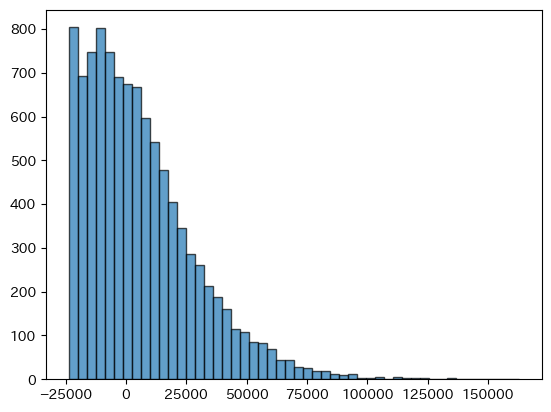

In [8]:
print("平均収支: ", np.mean(result))
print("標準偏差: ", np.std(result))
print("最大値: ", np.max(result))
print("最小値: ", np.min(result))
print("5%点: ", np.percentile(result, 5))
print("95%点: ", np.percentile(result, 95))
print('勝率: ', np.sum(np.array(result)>0)/len(result))
alpha = 10
print(f'{alpha}%点: ', np.percentile(result, alpha))
plt.hist(np.array(result), bins=50, edgecolor='black', alpha=0.7)
plt.show()